# **ספריות וקישור לדרייב**

In [ ]:
# יבוא ספריות והגדרות

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import drive

# חיבור לדרייב
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

Mounted at /content/drive


# **נתיבים והגדרות**

In [ ]:
# --- הגדרת נתיבים חדשים (מצביעים לתיקייה המסודרת) ---
BASE_DIR = "/content/drive/MyDrive/Elbit Project/Final_Dataset_Split"
TRAIN_DIR = os.path.join(BASE_DIR, 'train') # נתיב ל-70% מהתמונות
VAL_DIR = os.path.join(BASE_DIR, 'val')     # נתיב ל-15% מהתמונות
TEST_DIR = os.path.join(BASE_DIR, 'test')   # נתיב ל-15% הנותרים

# --- פרמטרים ---
IMG_SIZE = (224, 224) # תבנית שהרשת מצפה לקבל (VGG16 הוגדרה לגודל הזה)

# תטען לזיכרון 32 תמונות, תעביר את כולן ברשת במקביל,
# תחשב את הטעות הממוצעת של כולן, ורק אז תעדכן את המשקולות.
BATCH_SIZE = 32

# **חלוקה לגנרטורים - אימון \ אימות**

In [ ]:
# גנרטור לאימון (עם אוגמנטציה)

# === הגדרת הגנרטורים והאוגמנטציה (Data Augmentation) ===
# המטרה: מניעת Overfitting (שינון) ע"י יצירת וריאציות של התמונות "תוך כדי תנועה" (On-the-fly).
# בכל Epoch, הגנרטור מחליף את התמונה המקורית בגרסה מעובדת, כך שהמודל לעולם לא רואה את אותה תמונה פעמיים בדיוק.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,           # עיוות מינימלי
    zoom_range=0.05,            # זום מינימלי למניעת חיתוך
    horizontal_flip=True,
    fill_mode='nearest'
)

# גנרטור לוולידציה (בלי אוגמנטציה, רק rescale)
val_datagen = ImageDataGenerator(rescale=1./255)

# טעינה
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, # נתיב ישיר לתיקיית ה-Train
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True # כדי למנוע מהמודל ללמוד את סדר הנתונים ולהבטיח גיוון בכל באץ
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR, # נתיב ישיר לתיקיית ה-Val
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(f"המחלקות שזוהו: {class_names}")

Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.
המחלקות שזוהו: ['Black&White', 'Cartoon', 'Good', 'Multiple', 'Noise or blur', 'Sketch', 'Text', 'Toys']


# **התפלגות הנתונים**

Class                | Train      | Val        | Test      
----------------------------------------------------------
Black&White          | 84         | 18         | 18        
Cartoon              | 84         | 18         | 18        
Good                 | 84         | 18         | 18        
Multiple             | 84         | 18         | 18        
Noise or blur        | 84         | 18         | 18        
Sketch               | 84         | 18         | 18        
Text                 | 84         | 18         | 18        
Toys                 | 84         | 18         | 18        


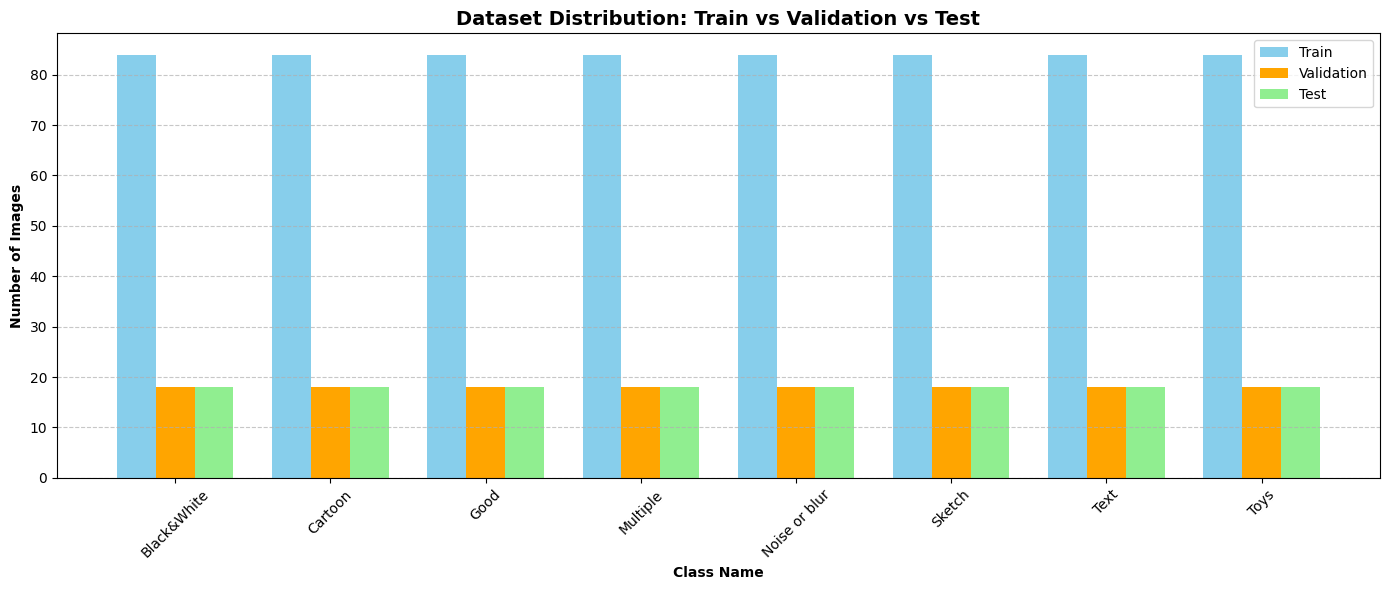

In [ ]:
# 1. פונקציה לספירת תמונות

def count_images_in_dir(directory, class_indices):
    counts = {}
    for class_name in class_indices.keys():
        class_path = os.path.join(directory, class_name)
        if os.path.exists(class_path):
            # ספירת קבצים בלבד
            counts[class_name] = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        else:
            counts[class_name] = 0
    return counts

# 2. ביצוע הספירה (Train vs Val vs Test)

classes = list(train_gen.class_indices.keys())
indices = train_gen.class_indices

# ספירה בפועל מהתיקיות
train_counts_map = count_images_in_dir(TRAIN_DIR, indices)
val_counts_map = count_images_in_dir(VAL_DIR, indices)
test_counts_map = count_images_in_dir(TEST_DIR, indices)

# המרה לרשימות לצורך הציור
train_values = [train_counts_map[c] for c in classes]
val_values = [val_counts_map[c] for c in classes]
test_values = [test_counts_map[c] for c in classes]

# 3. הדפסת טבלה מסודרת

print(f"{'Class':<20} | {'Train':<10} | {'Val':<10} | {'Test':<10}")
print("-" * 58)
for c, t, v, te in zip(classes, train_values, val_values, test_values):
    print(f"{c:<20} | {t:<10} | {v:<10} | {te:<10}")

# 4. ציור גרף השוואתי

x = np.arange(len(classes))  # מיקומי הברים
width = 0.25                 # רוחב הברים (מותאם ל-3 עמודות)

plt.figure(figsize=(14, 6))

# ברים של ה-Train
plt.bar(x - width, train_values, width, label='Train', color='skyblue')
# ברים של ה-Val
plt.bar(x, val_values, width, label='Validation', color='orange')
# ברים של ה-Test
plt.bar(x + width, test_values, width, label='Test', color='lightgreen')

plt.xlabel('Class Name', fontweight='bold')
plt.ylabel('Number of Images', fontweight='bold')
plt.title('Dataset Distribution: Train vs Validation vs Test', fontsize=14, fontweight='bold')
plt.xticks(x, classes, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **בדיקה מדגמית של האוגמנטציה לווידוא שלמות האובייקט, שימור המחלקה**

נבחרה תמונה אקראית: Image_8.jpg (מחלקה: Sketch)


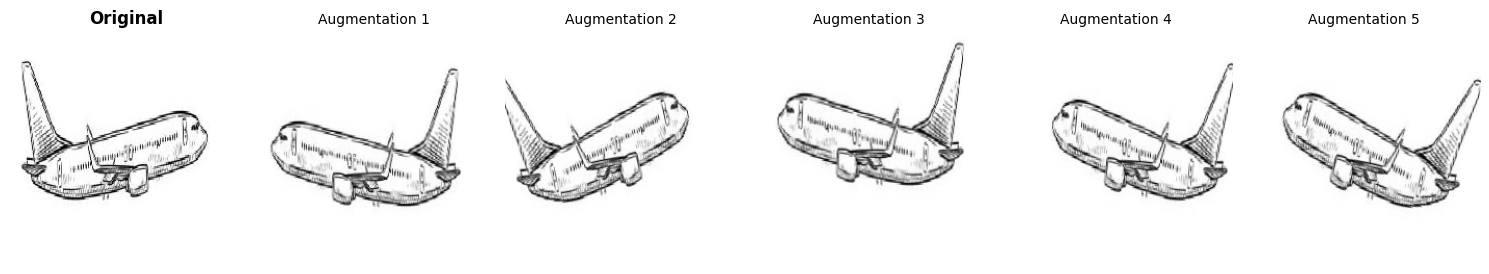

In [ ]:
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. בחירת תמונה אקראית מתוך סט האימון
random_class = random.choice(class_names)
class_path = os.path.join(TRAIN_DIR, random_class)

# סינון לקבצים בלבד כדי למנוע שגיאות
files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
random_file = random.choice(files)

img_path = os.path.join(class_path, random_file)
print(f"נבחרה תמונה אקראית: {random_file} (מחלקה: {random_class})")

# 2. טעינת התמונה המקורית ועיבוד ראשוני
img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = x.reshape((1,) + x.shape) # המרה למימד של באץ' (1, 224, 224, 3)

# 3. יצירת הויזואליזציה
plt.figure(figsize=(15, 6))

# הצגת התמונה המקורית
plt.subplot(1, 6, 1)
plt.imshow(img)
plt.title(f"Original", fontweight='bold')
plt.axis('off')

# 4. יצירת 5 וריאציות שונות באמצעות ה-Generator
i = 0
for batch in train_datagen.flow(x, batch_size=1):
    plt.subplot(1, 6, i+2)

    img_aug = batch[0]
    plt.imshow(img_aug)

    plt.title(f"Augmentation {i+1}", fontsize=10)
    plt.axis('off')

    i += 1
    if i >= 5: # עצירה אחרי 5 דוגמאות
        break

plt.tight_layout()
plt.show()

 סורק באצ'ים כדי למצוא נציג מכל מחלקה...
 מציג דוגמא לכל אחת מ- 8 המחלקות


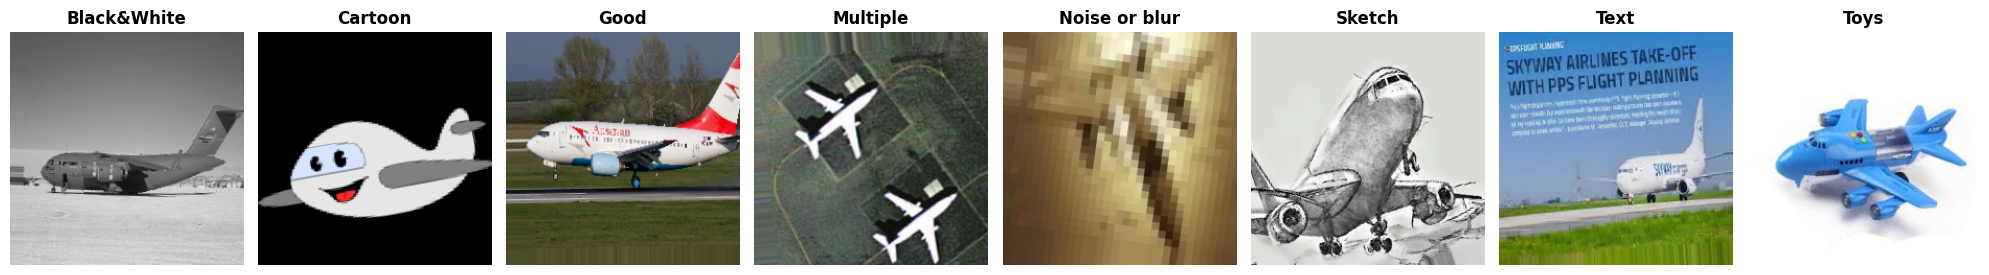

In [ ]:
# בדיקת ויזואליזציה
# המטרה: למצוא תמונה אחת לכל אחת מ-8 המחלקות
unique_images = {}
num_classes = len(class_names)

print(" סורק באצ'ים כדי למצוא נציג מכל מחלקה...")

# לולאה שרצה עד שנמצא נציג לכל מחלקה
while len(unique_images) < num_classes:
    batch_images, batch_labels = next(train_gen)

    for img, label in zip(batch_images, batch_labels):
        label_idx = int(label)

        # אם עדיין אין לנו תמונה למחלקה הזו - נשמור אותה
        if label_idx not in unique_images:
            unique_images[label_idx] = img

        # אם יש לנו את כולן, אפשר לעצור
        if len(unique_images) == num_classes:
            break

# סידור התמונות לפי סדר המחלקות (0 עד 7)
sorted_indices = sorted(unique_images.keys())

# תצוגה
print(f" מציג דוגמא לכל אחת מ- {num_classes} המחלקות")
plt.figure(figsize=(20, 5))
for i, idx in enumerate(sorted_indices):
    plt.subplot(1, num_classes, i+1)
    plt.imshow(unique_images[idx])
    plt.title(class_names[idx], fontweight='bold')
    plt.axis("off")

plt.tight_layout()
plt.show()

# **חיפוש היפר-פרמטרים - מה המודל שמציג את התוצאות הטובות ביותר**

מתחיל בהרצת 6 המודלים להשוואה...

--- Training Experiment: 1. Baseline (256) ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 640s 30s/step - accuracy: 0.2147 - loss: 2.1345 - val_accuracy: 0.6319 - val_loss: 1.1545
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 777ms/step - accuracy: 0.5817 - loss: 1.2121 - val_accuracy: 0.6944 - val_loss: 0.9036
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 761ms/step - accuracy: 0.6748 - loss: 0.9252 - val_accuracy: 0.7847 - val_loss: 0.7509
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 772ms/step - accuracy: 0.7839 - loss: 0.7248 - val_accuracy: 0.8125 - val_loss: 0.6442
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 787ms/step - accuracy: 0.7669 - loss: 0.6515 - val_accuracy: 0.8125 - val_loss: 0.5781
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 778ms/step - accuracy: 0.8096 - loss: 0.5962 - val_accuracy: 0.8194 - val_loss: 0.5698
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 763ms/step - accuracy: 0.8285 - loss: 0.5306 - val_accuracy: 0.8542 - val_loss: 0.5083
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 764ms/step - accuracy: 0.8257 - loss: 0.5165 - val_accur

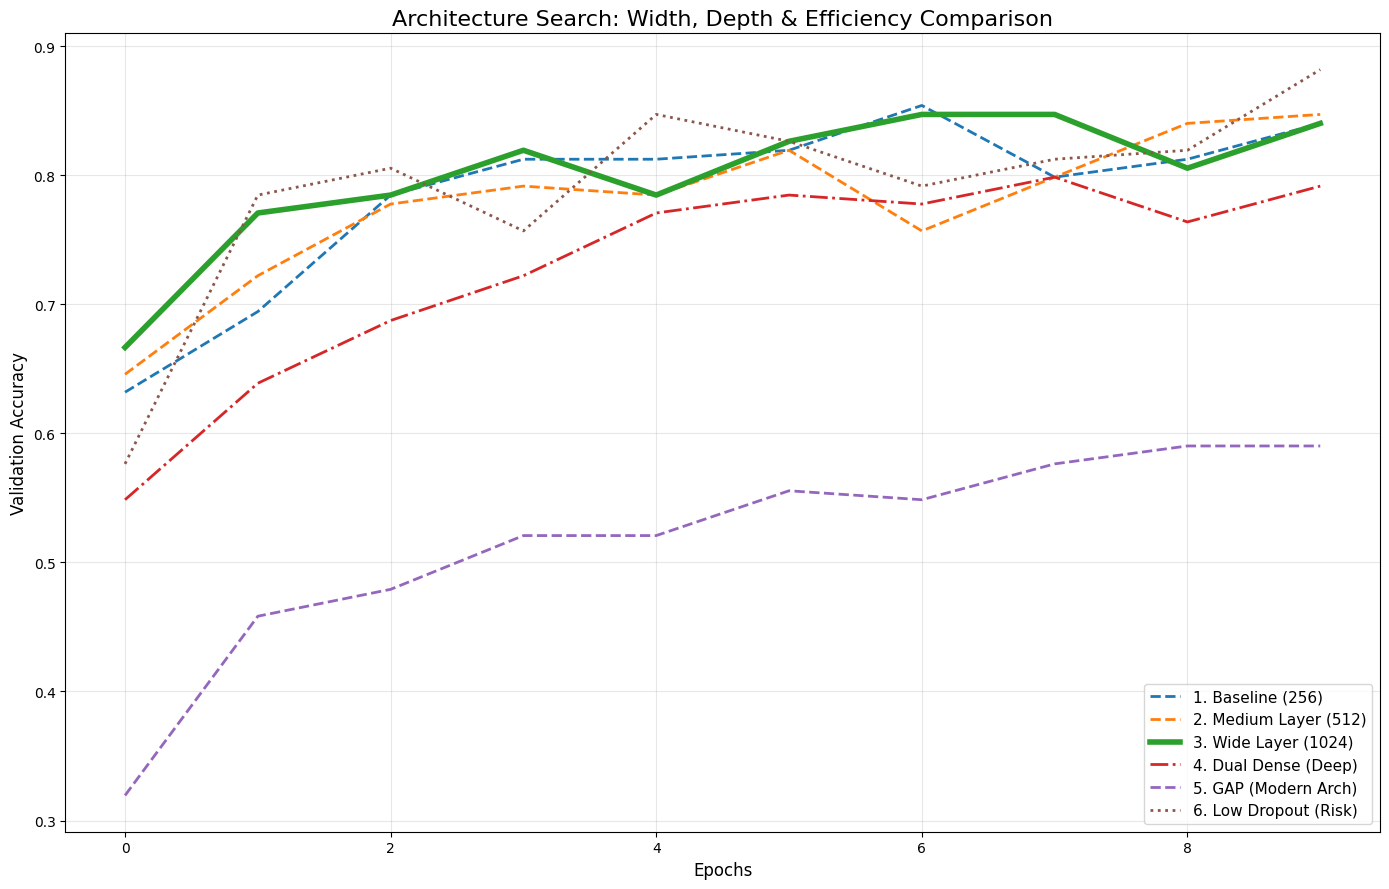

In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt

# השוואה מקיפה של 6 ארכיטקטורות

experiments = [
    # --- קבוצה 1: השפעת גודל השכבה (Width Scaling) ---
    # 1. בסיס: נקודת ייחוס סטנדרטית
    {'name': '1. Baseline (256)',          'dropout': 0.5, 'units': 256, 'lr': 1e-4, 'pooling': 'flatten'},

    # 2. בינוני: בדיקת השפעת הגדלת הקיבולת (Capacity)
    {'name': '2. Medium Layer (512)',      'dropout': 0.5, 'units': 512, 'lr': 1e-4, 'pooling': 'flatten'},

    # 3. High Capacity: קיבולת גבוהה ללמידת דפוסים מורכבים + (עם ריסון Dropout)
    {'name': '3. Wide Layer (1024) ',    'dropout': 0.5, 'units': 1024, 'lr': 1e-4, 'pooling': 'flatten'},

    # --- קבוצה 2: ארכיטקטורה ורגולריזציה ---
    # 4. עומק (Deep Head): עיבוד דו-שלבי (1024->256) לזיקוק המידע
    {'name': '4. Dual Dense (Deep)',       'dropout': 0.5, 'units': 'dual', 'lr': 1e-4, 'pooling': 'flatten'},

    # 5. GAP: מחליף את Flatten ע"י ממוצע לכל מפת פיצ'רים (הקטנת מימד דרסטית)
    {'name': '5. GAP (Modern Arch)',       'dropout': 0.5, 'units': 256, 'lr': 1e-4, 'pooling': 'avg'},

    # 6. רגולריזציה חלשה: בדיקת חשיבות ה-Dropout למניעת Overfitting
    {'name': '6. Low Dropout (0.2)',      'dropout': 0.2, 'units': 256, 'lr': 1e-4, 'pooling': 'flatten'},
]

histories = {}
print(f"מתחיל בהרצת 6 המודלים להשוואה...")

for exp in experiments:
    print(f"\n--- Training Experiment: {exp['name']} ---")

    # 1. טעינת הבסיס
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    x = base_model.output

    # 2. שיטת ה-Pooling
    if exp['pooling'] == 'avg':
        x = layers.GlobalAveragePooling2D()(x) # GAP: ממוצע לכל ערוץ
    else:
        x = layers.Flatten()(x)                # Flatten: יישור לקו אחד

    # 3. בניית ה-Head
    if exp['units'] == 'dual':
        x = layers.Dense(1024, activation='relu')(x)
        x = layers.Dropout(exp['dropout'])(x)
        x = layers.Dense(256, activation='relu')(x)
    else:
        x = layers.Dense(exp['units'], activation='relu')(x)

    x = layers.Dropout(exp['dropout'])(x)
    output = layers.Dense(len(class_names), activation='softmax')(x)

    model_temp = models.Model(inputs=base_model.input, outputs=output)

    model_temp.compile(optimizer=optimizers.Adam(learning_rate=exp['lr']),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

    # הרצה (10 אפוקים) - לקצר זמן ריצה, זיהוי מגמה כללית
    h = model_temp.fit(train_gen, epochs=10, validation_data=val_gen, verbose=1)
    histories[exp['name']] = h

# --- ציור הגרף ---
plt.figure(figsize=(14, 9))

for name, h in histories.items():
    if "1024" in name:
        plt.plot(h.history['val_accuracy'], linestyle='-', linewidth=2, label=name)
    elif "Low Dropout" in name:
        plt.plot(h.history['val_accuracy'], linestyle=':', linewidth=2, label=name)
    elif "Dual" in name:
        plt.plot(h.history['val_accuracy'], linestyle='-.', linewidth=2, label=name)
    else:
        plt.plot(h.history['val_accuracy'], linestyle='--', linewidth=2, label=name)

plt.title('Architecture Search: Width, Depth & Efficiency Comparison', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **הרצת המודל האידיאלי שנבחר ושמירת המשקולות לקובץ**

In [ ]:
import os
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16

# הגדרת הפרמטרים למודל הסופי הנבחר
# לאחר ניתוח השוואתי של ארכיטקטורות שונות, בחרתי בקונפיגורציה שהניבה
# את הדיוק הגבוה ביותר בוולידציה (High Accuracy) תוך שמירה על יעילות חישובית.
# המודל הנבחר משתמש ב-256 נוירונים ו-Dropout של 0.2.
BEST_UNITS = 256
BEST_DROPOUT = 0.2
BEST_LR = 0.0001
EPOCHS = 25

print(f"Selected Final Configuration: Units={BEST_UNITS}, Dropout={BEST_DROPOUT}")

# הגדרת Callbacks לניהול תהליך האימון
# 1. EarlyStopping: מפסיק את האימון אם אין שיפור ב-Loss של הוולידציה
# במשך 4 אפוקים רצופים, ומשחזר את המשקולות מהאפוק הטוב ביותר.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# 2. ModelCheckpoint: שומר את המודל לקובץ רק כאשר מתקבל שיפור בדיוק (Accuracy)
# על סט הוולידציה, כדי להבטיח שבסוף התהליך יישמר המודל המוצלח ביותר.
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# בניית המודל
# שימוש ב-VGG16 כבסיס (Feature Extractor) עם משקולות ImageNet מוקפאות.
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

# בניית שכבות הסיווג (Classification Head) לפי הפרמטרים הנבחרים
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(BEST_UNITS, activation='relu', name='final_dense_layer')(x)
x = layers.Dropout(BEST_DROPOUT)(x)
output_layer = layers.Dense(len(class_names), activation='softmax', name='prediction')(x)

step2_model = models.Model(inputs=base_model.input, outputs=output_layer, name="VGG16_Step2BestModel")

step2_model.compile(optimizer=optimizers.Adam(learning_rate=BEST_LR),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# הרצת האימון הסופי עם ה-Callbacks
print("Starting training for the final model...")
history = step2_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Selected Final Configuration: Units=256, Dropout=0.2
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting training for the final model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.2843 - loss: 2.0762 
Epoch 1: val_accuracy improved from -inf to 0.62500, saving model to /content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 369s 17s/step - accuracy: 0.2887 - loss: 2.0609 - val_accuracy: 0.6250 - val_loss: 1.0809
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.6379 - loss: 1.0452
Epoch 2: val_accuracy improved from 0.62500 to 0.76389, saving model to /content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 929ms/step - accuracy: 0.6394 - loss: 1.0403 - val_accuracy: 0.7639 - val_loss: 0.7773
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.7341 - loss: 0.7580
Epoch 3: val_accuracy improved from 0.76389 to 0.82639, saving model to /content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 941ms/step - accuracy: 0.7353 - loss: 0.7550 - val_accuracy: 0.8264 - val_loss: 0.6229
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.8366 - loss: 0.5285
Epoch 4: val_accuracy did not improve from 0.82639
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 874ms/step - accuracy: 0.8360 - loss: 0.5285 - val_accuracy: 0.8264 - val_loss: 0.5378
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.8692 - loss: 0.4740
Epoch 5: val_accuracy improved from 0.82639 to 0.83333, saving model to /content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 897ms/step - accuracy: 0.8685 - loss: 0.4745 - val_accuracy: 0.8333 - val_loss: 0.5151
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 848ms/step - accuracy: 0.8847 - loss: 0.3543
Epoch 6: val_accuracy did not improve from 0.83333
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 917ms/step - accuracy: 0.8846 - loss: 0.3549 - val_accuracy: 0.8264 - val_loss: 0.4946
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.9057 - loss: 0.3325
Epoch 7: val_accuracy improved from 0.83333 to 0.87500, saving model to /content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9055 - loss: 0.3325 - val_accuracy: 0.8750 - val_loss: 0.4874
Epoch 8/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.9488 - loss: 0.2523
Epoch 8: val_accuracy did not improve from 0.87500
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 876ms/step - accuracy: 0.9480 - loss: 0.2537 - val_accuracy: 0.8750 - val_loss: 0.4388
Epoch 9/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.9375 - loss: 0.2549
Epoch 9: val_accuracy did not improve from 0.87500
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 759ms/step - accuracy: 0.9371 - loss: 0.2550 - val_accuracy: 0.8681 - val_loss: 0.4411
Epoch 10/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.9405 - loss: 0.2442
Epoch 10: val_accuracy did not improve from 0.87500
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 765ms/step - accuracy: 0.9404 - loss: 0.2444 - val_accuracy: 0.8750 - val_loss: 0.4428
Epoch 11/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.9311 - loss: 0.2433
Epoch 11: val_accuracy did not 

21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 920ms/step - accuracy: 0.9512 - loss: 0.1955 - val_accuracy: 0.8889 - val_loss: 0.4014
Epoch 13/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.9300 - loss: 0.2203
Epoch 13: val_accuracy did not improve from 0.88889
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 896ms/step - accuracy: 0.9310 - loss: 0.2186 - val_accuracy: 0.8681 - val_loss: 0.4107
Epoch 14/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.9478 - loss: 0.1803
Epoch 14: val_accuracy improved from 0.88889 to 0.89583, saving model to /content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9484 - loss: 0.1796 - val_accuracy: 0.8958 - val_loss: 0.3887
Epoch 15/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 870ms/step - accuracy: 0.9546 - loss: 0.1597
Epoch 15: val_accuracy did not improve from 0.89583
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 938ms/step - accuracy: 0.9549 - loss: 0.1597 - val_accuracy: 0.8819 - val_loss: 0.4181
Epoch 16/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.9673 - loss: 0.1296
Epoch 16: val_accuracy did not improve from 0.89583
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 776ms/step - accuracy: 0.9667 - loss: 0.1302 - val_accuracy: 0.8403 - val_loss: 0.4338
Epoch 17/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.9786 - loss: 0.1307
Epoch 17: val_accuracy did not improve from 0.89583
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 779ms/step - accuracy: 0.9782 - loss: 0.1315 - val_accuracy: 0.8542 - val_loss: 0.4148
Epoch 18/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.9799 - loss: 0.1357
Epoch 18: val_accuracy did 

# **טעינת המודל מהקובץ**

In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/פרויקט גמר רשתות נוירונים/best_model_vgg16.h5"

# --- מנגנון בטיחות: בודק אם כבר הרצנו את זה בעבר ---
if os.path.exists(model_path):
    model = load_model(model_path)
    print("המודל נטען בהצלחה!.")

else:
    print("נתיב לא נמצא! בדוק חיבור לדרייב, נתיב או הרץ את המודל מחדש")


המודל נטען בהצלחה!.


# **גרפי וויזואליזציה סופית**

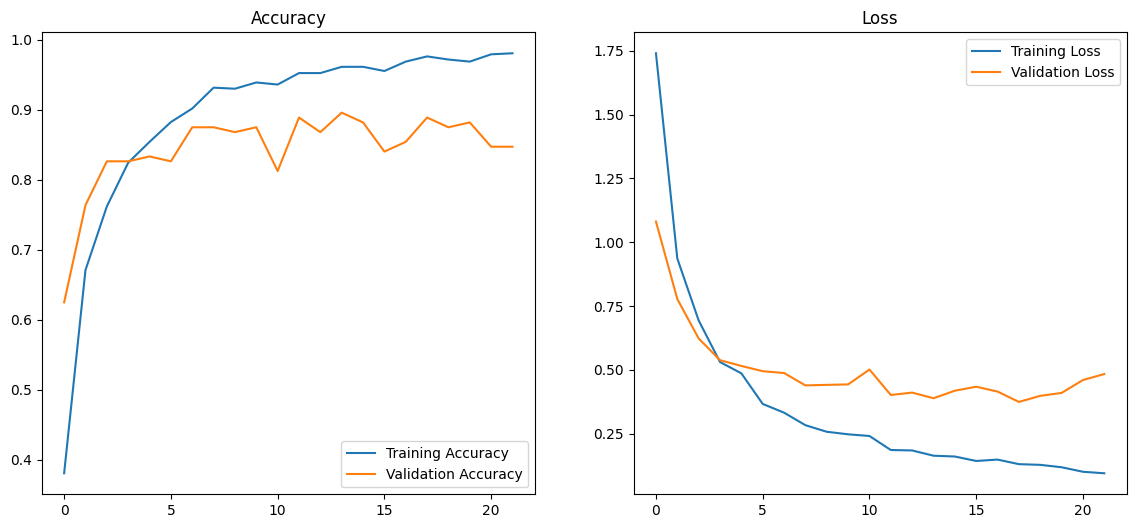

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.show()


# **הצגת מטריצות ואחוזי הצלחה**

מכין גנרטורים לבדיקה (Train + Val)...
Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.

מעבד תחזיות עבור: TRAIN Set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 390ms/step


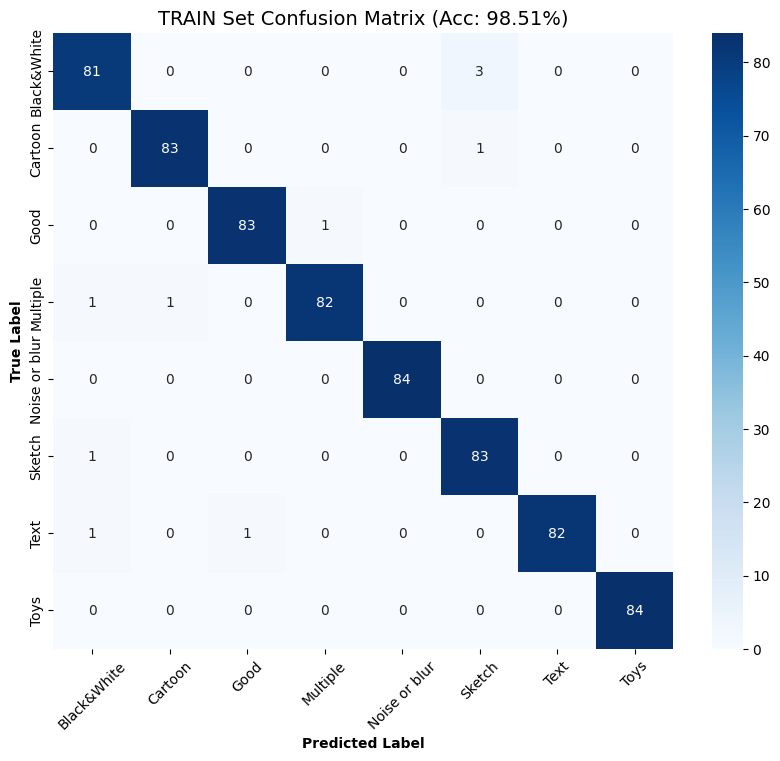


מעבד תחזיות עבור: VALIDATION Set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step


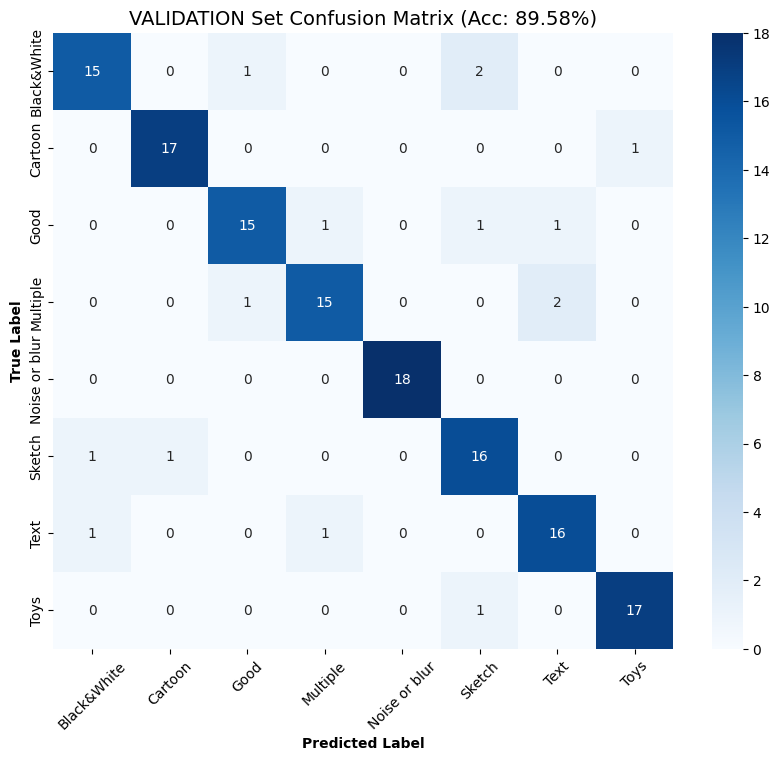


 מכין תצוגה ויזואלית של טעויות והצלחות...


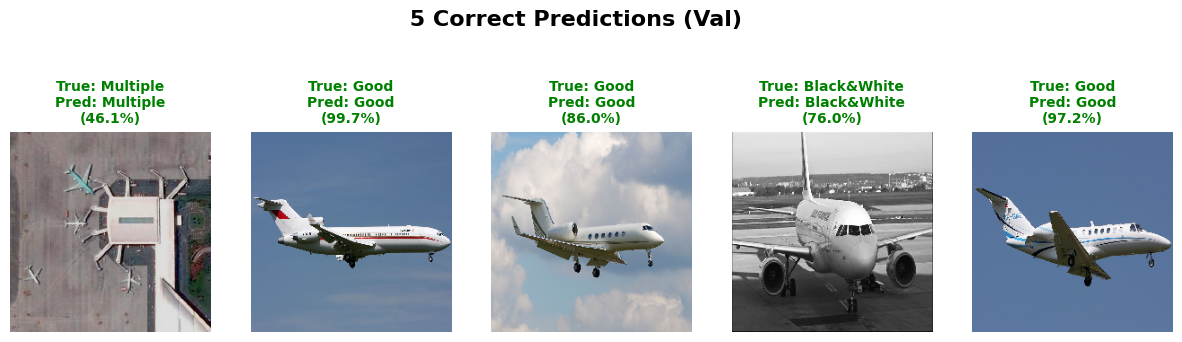

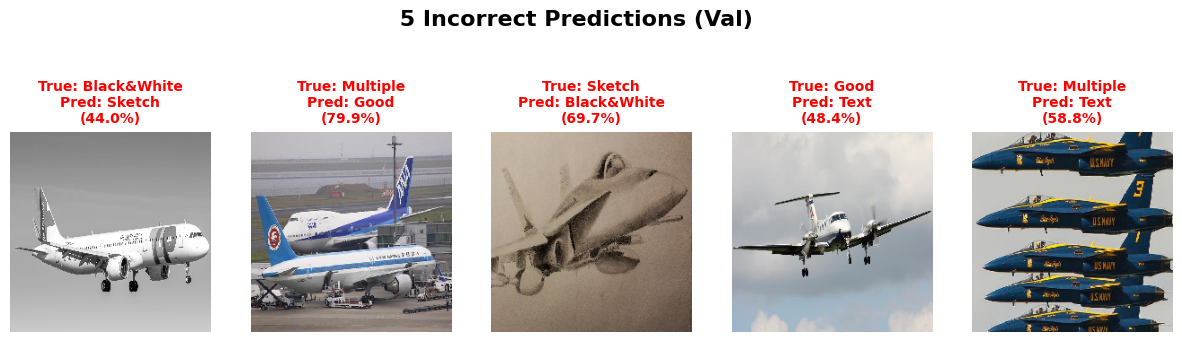

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. הכנת נתונים ללא ערבוב

print("מכין גנרטורים לבדיקה (Train + Val)...")

eval_datagen = ImageDataGenerator(rescale=1./255)

# גנרטור TRAIN (לבדיקת שינון)
train_gen_eval = eval_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# גנרטור VAL (לבדיקת ביצועים)
val_gen_eval = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# שמות המחלקות
class_names = list(train_gen_eval.class_indices.keys())

# 2. פונקציה לחישוב והצגת מטריצה

def analyze_and_plot(generator, title_set):
    print(f"\nמעבד תחזיות עבור: {title_set}...")
    generator.reset()

    # חיזוי
    preds_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds_probs, axis=1)
    y_true = generator.classes

    # חישוב מטריצה ודיוק
    cm = confusion_matrix(y_true, y_pred)
    acc = np.mean(y_true == y_pred)

    # ציור היט-מאפ (Heatmap)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title_set} Confusion Matrix (Acc: {acc*100:.2f}%)', fontsize=14)
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.xticks(rotation=45)
    plt.show()

    # החזרת הנתונים כדי להשתמש בהם לתמונות
    return preds_probs, y_pred, y_true

# 3. הרצת הבדיקות (מטריצות)

# א. מטריצה ל-TRAIN
analyze_and_plot(train_gen_eval, "TRAIN Set")

# ב. מטריצה ל-VAL (שומרים את התוצאות להצגת התמונות)
val_probs, val_preds, val_true = analyze_and_plot(val_gen_eval, "VALIDATION Set")

# 4. הצגת תמונות (הצלחות vs כישלונות ב-VAL)

print("\n מכין תצוגה ויזואלית של טעויות והצלחות...")

# טעינת התמונות לזיכרון לתצוגה
val_images = []
val_gen_eval.reset()
for i in range(len(val_gen_eval)):
    batch_imgs, _ = next(val_gen_eval)
    val_images.extend(batch_imgs)
val_images = np.array(val_images)

# אינדקסים
correct_indices = np.where(val_preds == val_true)[0]
incorrect_indices = np.where(val_preds != val_true)[0]

def plot_images_grid(indices, title, is_error=False):
    if len(indices) == 0:
        print(f"אין תמונות להציג עבור: {title}")
        return

    n_show = min(5, len(indices))
    selected_indices = np.random.choice(indices, n_show, replace=False)

    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)

    for i, idx in enumerate(selected_indices):
        img = val_images[idx]
        true_lbl = class_names[val_true[idx]]
        pred_lbl = class_names[val_preds[idx]]
        conf = np.max(val_probs[idx]) * 100

        col = 'red' if is_error else 'green'

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_lbl}\nPred: {pred_lbl}\n({conf:.1f}%)", color=col, fontsize=10, fontweight='bold')
        plt.axis("off")
    plt.show()

# הצגה
plot_images_grid(correct_indices, " 5 Correct Predictions (Val)", is_error=False)

if len(incorrect_indices) > 0:
    plot_images_grid(incorrect_indices, " 5 Incorrect Predictions (Val)", is_error=True)
else:
    print("\n המודל צדק ב-100% מהמקרים ב-Validation.")

# **הערכת המודל על סט המבחן**

In [ ]:
# --- הגדרת גנרטור לטסט ---
test_datagen = ImageDataGenerator(rescale=1./255) # רק נרמול, בלי אוגמנטציה

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,  # הנתיב לתיקיית ה-test
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# --- ביצוע המבחן הסופי ---
print("\n מבצע הערכה על סט הטסט (Test Set)...")
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n דיוק סופי על הטסט: {test_acc*100:.2f}%")

Found 144 images belonging to 8 classes.

 מבצע הערכה על סט הטסט (Test Set)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.8384 - loss: 0.5126

 דיוק סופי על הטסט: 86.81%


נערך חיזוי על סט הטסט...
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step


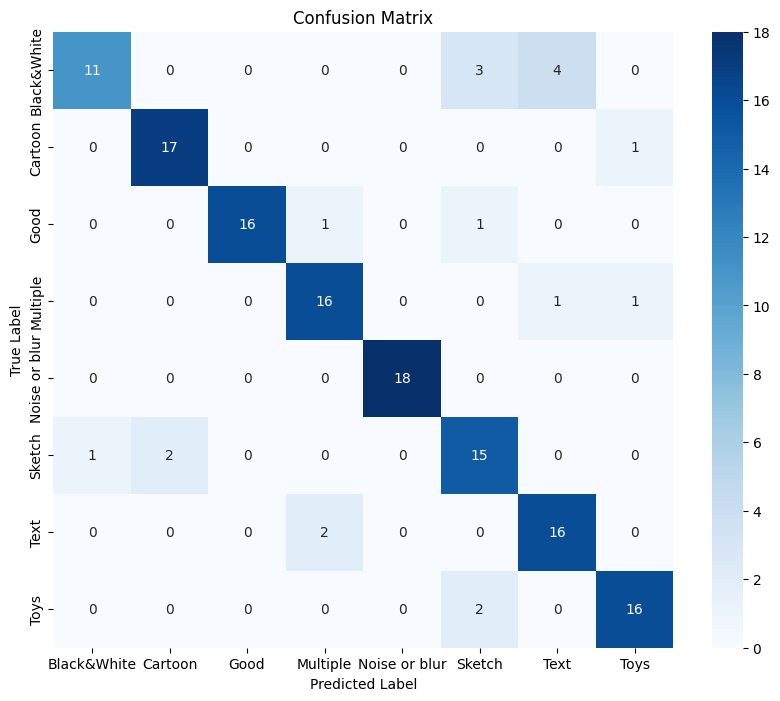


Classification Report:

               precision    recall  f1-score   support

  Black&White       0.92      0.61      0.73        18
      Cartoon       0.89      0.94      0.92        18
         Good       1.00      0.89      0.94        18
     Multiple       0.84      0.89      0.86        18
Noise or blur       1.00      1.00      1.00        18
       Sketch       0.71      0.83      0.77        18
         Text       0.76      0.89      0.82        18
         Toys       0.89      0.89      0.89        18

     accuracy                           0.87       144
    macro avg       0.88      0.87      0.87       144
 weighted avg       0.88      0.87      0.87       144



In [ ]:
# 1. ביצוע חיזוי על כל סט הטסט

print("נערך חיזוי על סט הטסט...")
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1) # הפיכת הסתברויות למספר מחלקה (0, 1, 2...)
y_true = test_gen.classes # התוויות האמיתיות

# 2. יצירת מטריצת הבלבול

cm = confusion_matrix(y_true, y_pred)

# 3. ציור הגרף

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 4. דוח טקסטואלי מפורט

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

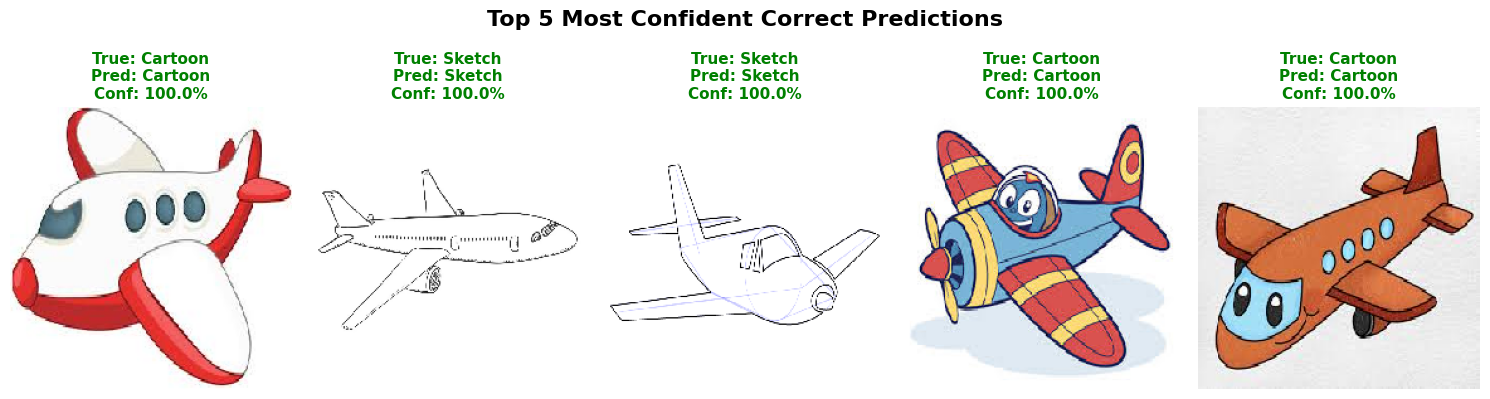

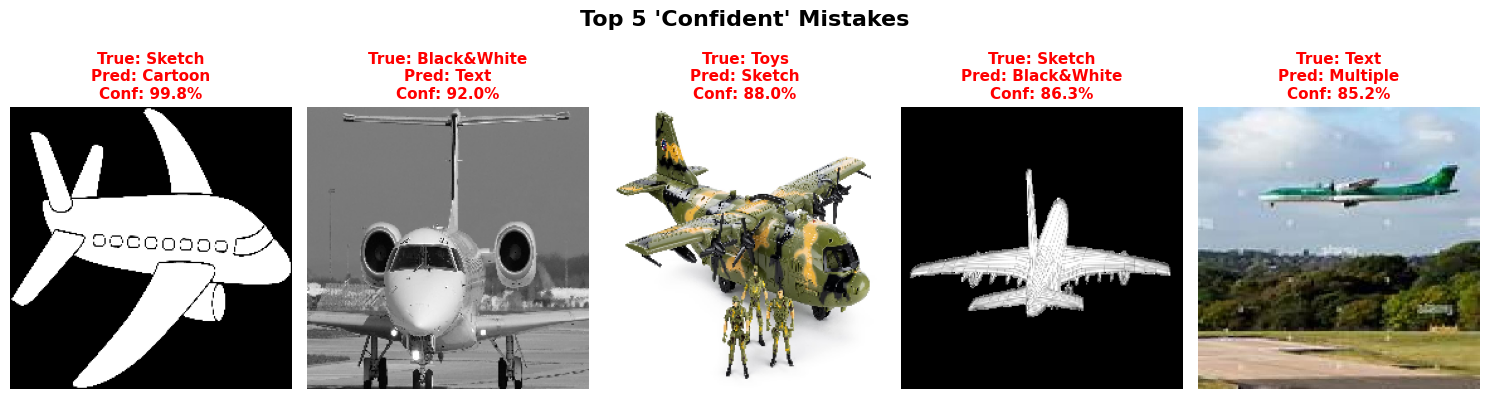

In [ ]:
from tensorflow.keras.preprocessing import image

# 5. הצגת הצלחות וכישלונות (ממוין לפי רמת ביטחון)

# שליפת רשימת הקבצים
file_paths = test_gen.filepaths

# מציאת אינדקסים
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

# שליפת רמות הביטחון (Confidence) לכל התחזיות
confidences = np.max(y_pred_prob, axis=1)

def plot_sorted_predictions(indices, title, color, sort_descending=True):
    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)

    if len(indices) == 0:
        print(f"לא נמצאו דוגמאות עבור: {title}")
        return

    # שולפים את הביטחון רק עבור האינדקסים הרלוונטיים
    relevant_confidences = confidences[indices]

    # מיון האינדקסים (Argsort)
    if sort_descending:
        # מהגבוה לנמוך (הכי בטוחים)
        sorted_order = np.argsort(relevant_confidences)[::-1]
    else:
        # מהנמוך לגבוה (הכי פחות)
        sorted_order = np.argsort(relevant_confidences)

    # לוקחים את ה-5 הראשונים אחרי המיון
    top_n_indices = indices[sorted_order[:5]]

    for i, idx in enumerate(top_n_indices):
        img_path = file_paths[idx]
        img = image.load_img(img_path, target_size=(224, 224))

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = confidences[idx] * 100

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
                  color=color, fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- הפעלת הפונקציות ---

# 1. ההצלחות הכי גדולות (הכי בטוח בעצמו)
plot_sorted_predictions(correct_indices, "Top 5 Most Confident Correct Predictions", 'green', sort_descending=True)

# 2. הטעויות הכי "קשות" (המודל היה בטוח שהוא צודק, אבל טעה)!
if len(incorrect_indices) > 0:
    plot_sorted_predictions(incorrect_indices, "Top 5 'Confident' Mistakes", 'red', sort_descending=True)
else:
    print("אין טעויות להציג.")

# **הרצת תמונות חדשות מהעולם**

 מציג תוצאות ויזואליות...



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


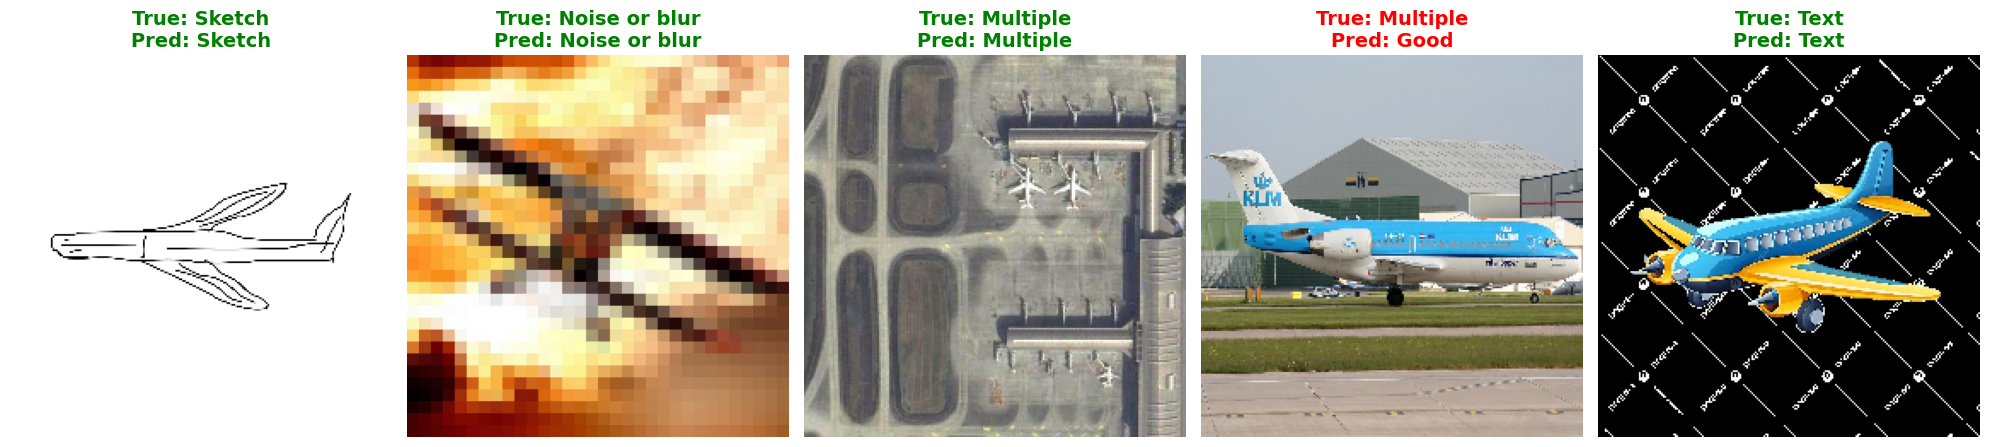

In [ ]:
# קישור לתיקיית מקור
base_dir = "/content/drive/MyDrive/Elbit Project/Images Data for Coding"

# רשימה של זוגות: (שם קובץ, הלייבל האמיתי)
test_data = [
    ('test_image.jpg', 'Sketch'),
    ('test_image2.jpg', 'Noise or blur'),
    ('test_image3.jpg', 'Multiple'),
    ('test_image4.jpg', 'Multiple'),
    ('test_image5.png', 'Text')
]

#  לולאת עיבוד ותצוגה

plt.figure(figsize=(20, 6)) # רוחב גדול
print(" מציג תוצאות ויזואליות...\n")

for i, (file_name, true_label) in enumerate(test_data):
    full_path = os.path.join(base_dir, file_name)

    # 1. בדיקה שהקובץ קיים
    if not os.path.exists(full_path):
        continue

    # 2. טעינה ועיבוד
    img = image.load_img(full_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = img_batch / 255.0  # נירמול

    # 3. חיזוי
    probs = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(probs)
    pred_label = class_names[pred_idx]

    # 4. בדיקת פרדיקציה וקביעת צבע
    is_correct = (pred_label == true_label)
    title_color = 'green' if is_correct else 'red'

    # טקסט לכותרת (לייבל אמיתי לעומת מה המודל חשב)
    title_text = f"True: {true_label}\nPred: {pred_label}"

    # 5. הוספה לגרף
    plt.subplot(1, len(test_data), i+1)
    plt.imshow(img)
    plt.axis('off')

    plt.title(title_text, fontsize=14, color=title_color, fontweight='bold')

# סידור והצגה
plt.tight_layout()
plt.show()